# Credit Risk Data Cleaning and Exploratory Data Analysis

This notebook performs initial data inspection, cleaning, and exploratory analysis on a consumer credit risk dataset.

The goal is to understand borrower characteristics, identify potential data quality issues, and explore relationships between financial variables and loan default behavior.

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load Credit Risk Dataset

Load the raw credit risk dataset and inspect the initial structure of the data.

In [2]:
# Load dataset
credit = pd.read_csv(
    "/Users/Mandy/Desktop/GithubProjects/credit-risk-prediction/data/credit_risk_dataset.csv"
)

# Display dataset preview
credit.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


# Dataset Structure Inspection

Inspect dataset dimensions, column names, and data types before cleaning and analysis.

In [3]:
# Display dataset shape
credit.shape

(32581, 12)

In [4]:
# Display column names
credit.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [5]:
# Display data types
credit.dtypes

person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object

# Data Quality Assessment

Evaluate the dataset for missing values, duplicated observations, and potential data quality issues before modeling.

Understanding data quality is an essential step in structured machine learning workflows.

In [6]:
# Check missing values
missing_values = credit.isnull().sum()

missing_values

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

## Duplicate Observation Inspection

Check whether the dataset contains duplicated borrower records.

In [7]:
# Check duplicated rows
credit.duplicated().sum()

165

## Numerical Variable Summary Statistics

Review descriptive statistics for numerical borrower and loan variables.

In [8]:
# Summary statistics
credit.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


# Initial Data Quality Findings

Several important data quality observations were identified during the initial inspection process:

- The dataset contains 32,581 borrower observations and 12 variables.
- Some numerical variables contain missing values, particularly:
  - `person_emp_length`
  - `loan_int_rate`
- The dataset also contains 165 duplicated borrower records.
- Summary statistics suggest the presence of potential (unrealistic) outliers:
  - Maximum borrower age is 144 years old
  - Maximum employment length is 123 years

These observations indicate that additional cleaning and preprocessing steps will likely be required before predictive modeling.

# Outlier Removal

Remove unrealistic borrower records that may distort downstream statistical analysis and machine learning performance.

Observations with implausible ages and employment lengths are treated as potential data quality issues.

In [9]:
# Remove unrealistic borrower ages
credit = credit[
    credit["person_age"] <= 90
]

# Check updated maximum age
credit["person_age"].max()

84

In [10]:
# Remove unrealistic employment lengths
credit = credit[
    credit["person_emp_length"] <= 60
]

# Check updated maximum employment length
credit["person_emp_length"].max()

41.0

In [11]:
# Remove duplicated rows
credit = credit.drop_duplicates()

# Check remaining duplicated rows
credit.duplicated().sum()

0

# Data Cleaning Summary

Several preprocessing steps were performed to improve dataset quality:

- Removed unrealistic borrower ages above 90 years old
- Removed implausible employment lengths above 60 years
- Removed duplicated borrower observations

These cleaning steps help reduce the impact of erroneous records and improve the reliability of downstream analysis and predictive modeling.

In [12]:
# Check updated dataset shape
credit.shape

(31521, 12)

# Target Variable Analysis

Inspect the distribution of loan default outcomes across the dataset.

The variable `loan_status` represents whether a borrower defaulted on a loan:

- 0 = Non-default
- 1 = Default

Understanding class balance is important before building predictive models.

In [13]:
# Display target distribution
credit["loan_status"].value_counts()

0    24714
1     6807
Name: loan_status, dtype: int64

In [14]:
# Display target proportions
credit["loan_status"].value_counts(normalize=True)

0    0.784049
1    0.215951
Name: loan_status, dtype: float64

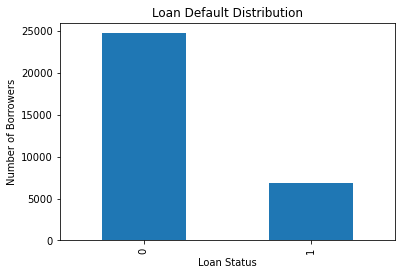

In [15]:
# Plot target distribution
credit["loan_status"].value_counts().plot(
    kind="bar"
)

plt.title("Loan Default Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Borrowers")

plt.show()

# Target Distribution Findings

The dataset exhibits moderate class imbalance:

- Approximately 78% of borrowers are non-default cases
- Approximately 22% of borrowers are default cases

This imbalance is common in credit risk modeling problems and may influence predictive model behavior.

The target distribution suggests that evaluation metrics beyond simple accuracy may be necessary during model assessment.

# Borrower Income Analysis

Analyze the relationship between borrower income levels and loan default outcomes.

In [16]:
# Compare average income by loan status
credit.groupby(
    "loan_status"
)["person_income"].mean()

loan_status
0    71067.653476
1    49930.379462
Name: person_income, dtype: float64

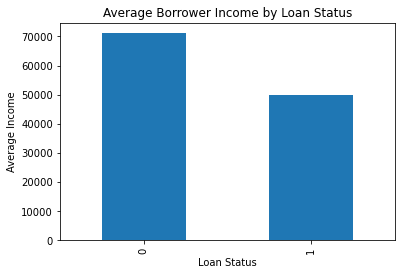

In [17]:
# Plot average borrower income by loan status
credit.groupby(
    "loan_status"
)["person_income"].mean().plot(
    kind="bar"
)

plt.title("Average Borrower Income by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Average Income")

plt.show()

# Income Analysis Findings

Borrowers who defaulted on loans tend to have lower average income levels compared to non-default borrowers.

Key observations:

- Non-default borrowers have an average income of approximately $71k
- Default borrowers have an average income of approximately $50k

This suggests that borrower income may serve as an important predictive feature in credit risk modeling.

Lower income levels may indicate reduced repayment capacity and higher financial vulnerability.

# Loan Grade Analysis

Analyze default behavior across different loan grades.

Loan grades represent internal assessments of borrower credit quality and lending risk.

In [18]:
# Default rate by loan grade
credit.groupby(
    "loan_grade"
)["loan_status"].mean()

loan_grade
A    0.095631
B    0.159668
C    0.203175
D    0.587771
E    0.642482
F    0.703390
G    0.984375
Name: loan_status, dtype: float64

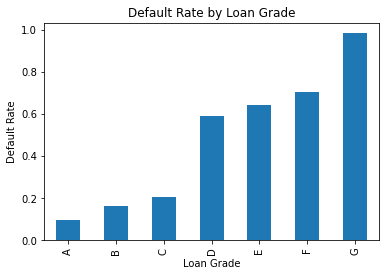

In [19]:
# Plot default rate by loan grade
credit.groupby(
    "loan_grade"
)["loan_status"].mean().plot(
    kind="bar"
)

plt.title("Default Rate by Loan Grade")
plt.xlabel("Loan Grade")
plt.ylabel("Default Rate")

plt.show()

# Loan Grade Findings

Loan grade demonstrates a strong relationship with borrower default risk.

Key observations:

- Higher-quality grades (A–C) exhibit relatively low default rates
- Lower-quality grades (D–G) show dramatically higher default probabilities
- Grade G loans exhibit an extremely high default rate approaching 100%

These findings suggest that loan grade is likely one of the most important predictive features in the dataset.

The results align with real-world lending practices, where internal credit grading systems are designed to capture borrower risk profiles.

# Interest Rate Analysis

Analyze the relationship between loan interest rates and borrower default behavior.

In [20]:
# Compare average interest rate by loan status
credit.groupby(
    "loan_status"
)["loan_int_rate"].mean()

loan_status
0    10.466820
1    13.130713
Name: loan_int_rate, dtype: float64

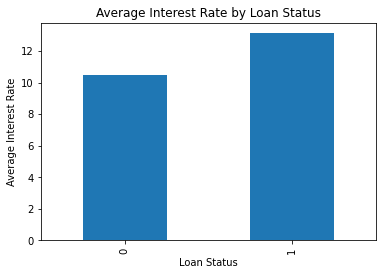

In [21]:
# Plot average interest rate by loan status
credit.groupby(
    "loan_status"
)["loan_int_rate"].mean().plot(
    kind="bar"
)

plt.title("Average Interest Rate by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Average Interest Rate")

plt.show()

# Interest Rate Findings

Defaulted borrowers tend to receive loans with higher average interest rates compared to non-default borrowers.

Key observations:

- Non-default borrowers have an average interest rate of approximately 10.5%
- Default borrowers have an average interest rate of approximately 13.1%

This pattern suggests that lenders may already recognize higher-risk borrowers and compensate by charging higher interest rates.

However, despite higher pricing, elevated default rates still persist among riskier borrowers.

# Correlation Analysis

Inspect relationships between numerical borrower and loan variables.

Correlation analysis helps identify which variables may have stronger relationships with loan default behavior and borrower risk.

In [22]:
# Select numerical columns only
numeric_credit = credit.select_dtypes(
    include=["int64", "float64"]
)

# Compute correlations
correlations = numeric_credit.corr()

correlations

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
person_age,1.000000,0.142133,0.173112,0.052443,0.009504,-0.023028,-0.040584,0.878612
person_income,0.142133,1.000000,0.154391,0.313909,-0.003729,-0.164878,-0.293656,0.124080
person_emp_length,0.173112,0.154391,1.000000,0.111074,-0.058474,-0.086331,-0.058435,0.149841
loan_amnt,0.052443,0.313909,0.111074,1.000000,0.146017,0.112591,0.577208,0.042738
loan_int_rate,0.009504,-0.003729,-0.058474,0.146017,1.000000,0.339952,0.123343,0.014520
loan_status,-0.023028,-0.164878,-0.086331,0.112591,0.339952,1.000000,0.380092,-0.017702
loan_percent_income,-0.040584,-0.293656,-0.058435,0.577208,0.123343,0.380092,1.000000,-0.030575
cb_person_cred_hist_length,0.878612,0.124080,0.149841,0.042738,0.014520,-0.017702,-0.030575,1.000000


In [23]:
import seaborn as sns

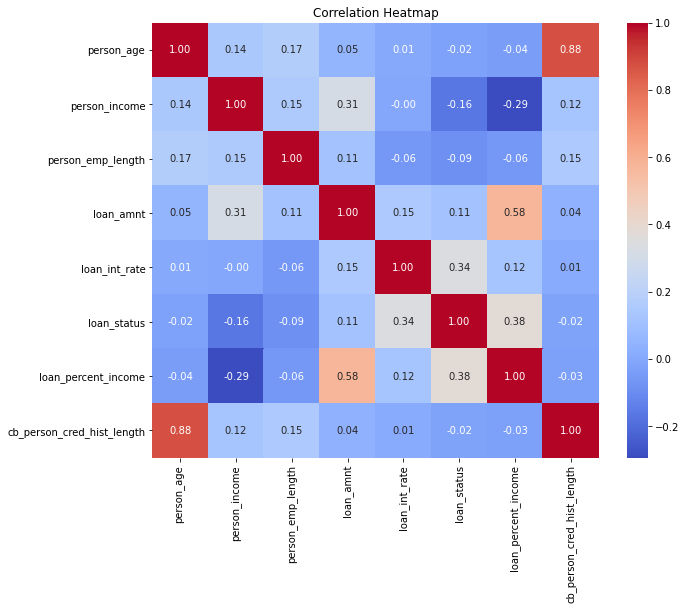

In [24]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlations,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# Correlation Analysis Findings

Several meaningful relationships emerge from the correlation analysis:

Key observations:

- Borrower age is strongly correlated with credit history length
- Larger loan amounts are associated with higher default probability
- Higher interest rates are positively associated with loan default risk
- Higher borrower income appears negatively associated with default behavior

These relationships are economically intuitive and align with real-world credit risk dynamics.

The findings suggest that variables related to borrower financial strength, loan pricing, and loan size may contribute meaningful predictive power in downstream machine learning models.

# Save Cleaned Dataset

Save the cleaned dataset for feature engineering and machine learning preparation.

In [25]:
credit.to_csv(
    "/Users/Mandy/Desktop/GithubProjects/credit-risk-prediction/data/credit_risk_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
